## Definición de Clases de Comunicación
Las clases de comunicación se pueden sacar a ojo, pero python ayuda a esto con estas librerias y código

In [10]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [11]:
# Matriz y Matriz de Alcanzabilidad
Q = np.array([
    [0.5, 0.5, 0.0, 0.0],
    [0.3, 0.7, 0.0, 0.0],
    [0.2, 0.1, 0.4, 0.3],
    [0.0, 0.0, 0.0, 1.0],
])

alcanzabilidad_Q = np.linalg.matrix_power(np.eye(4) + Q, 3) > 0
print("Matriz de alcanzabilidad de Q:")
print(alcanzabilidad_Q)

Matriz de alcanzabilidad de Q:
[[ True  True False False]
 [ True  True False False]
 [ True  True  True  True]
 [False False False  True]]


Clases de comunicación: [{0, 1}, {3}, {2}]


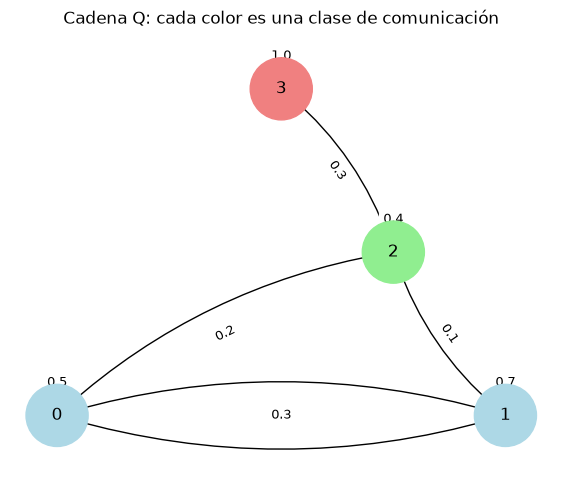

In [19]:
# Creación del Digrafo
G_Q = nx.DiGraph()
for i in range(4):
    for j in range(4):
        if Q[i, j] > 0:
            G_Q.add_edge(i, j, weight=Q[i, j])

# Las clases de comunicación son los nodos fuertemente conexos del grafo
clases = list(nx.strongly_connected_components(G_Q))
print("Clases de comunicación:", clases)

# Dibujo del grafo
paleta = ["lightblue", "lightcoral", "lightgreen", "khaki"]
color_de = {nodo: paleta[k % len(paleta)]
            for k, clase in enumerate(clases) for nodo in clase}

pos = nx.planar_layout(G_Q) #Puede ser circular, plano, etc.
plt.figure(figsize=(7, 6))
nx.draw_networkx_nodes(G_Q, pos, node_color=[color_de[n] for n in G_Q.nodes()], node_size=2000)
nx.draw_networkx_labels(G_Q, pos)
nx.draw_networkx_edges(G_Q, pos, connectionstyle="arc3,rad=0.15", arrowsize=20)
etiquetas = {(u, v): f"{d['weight']:.1f}" for u, v, d in G_Q.edges(data=True)}
nx.draw_networkx_edge_labels(G_Q, pos, edge_labels=etiquetas, font_size=9)
plt.title("Cadena Q: cada color es una clase de comunicación")
plt.axis("off")
plt.show()

### Ejercicios de Clase

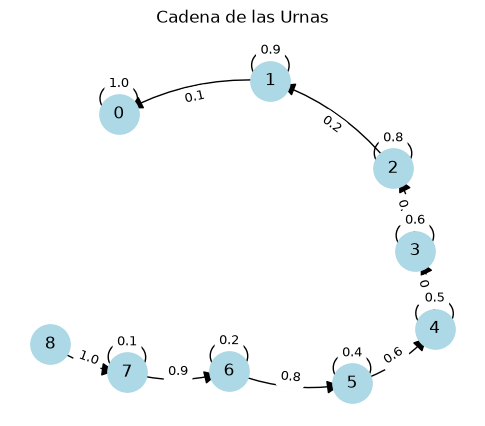

Cantidad de urnas no vacias


In [47]:
UP = np.array([
    [1,   0,   0,   0,   0,   0,   0,   0, 0],
    [1/8, 7/8, 0,   0,   0,   0,   0,   0, 0],
    [0,   2/8, 6/8, 0,   0,   0,   0,   0, 0],
    [0,   0,   3/8, 5/8, 0,   0,   0,   0, 0],
    [0,   0,   0,   4/8, 4/8, 0,   0,   0, 0],
    [0,   0,   0,   0,   5/8, 3/8, 0,   0, 0],
    [0,   0,   0,   0,   0,   6/8, 2/8, 0, 0],
    [0,   0,   0,   0,   0,   0,   7/8, 1/8, 0],
    [0,   0,   0,   0,   0,   0,   0,   1,   0]
])

# Creación del Digrafo
estados = ["0","1","2","3","4","5","6","7","8"]
G = nx.DiGraph()

for i, origen in enumerate(estados):
    for j, destino in enumerate(estados):
        if UP[i,j] > 0:
            G.add_edge(origen, destino, weight=UP[i, j])

pos = nx.spring_layout(G, seed=26)
plt.figure(figsize=(6,5))
nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=800)
nx.draw_networkx_labels(G, pos)
nx.draw_networkx_edges(G, pos, connectionstyle="arc3,rad=0.15", arrowsize=20)
etiquetas = {(u, v): f"{d['weight']:.1f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=etiquetas, font_size=9)
plt.title("Cadena de las Urnas")
plt.axis("off")
plt.show()
print("Cantidad de urnas no vacias")

## Distribucion Estacionaria
La frecuencia de visitas a un estado <-> Tiempo Medio de retorno

**Probabilidades de llegada de alguna vez de i a j**

Para dos estados diferentes, f es la probabilidad de que, comenzando en el estado i, la cadena llegue alguna vez al estado j

**Si i es recurrente y i <-> j**

Entonces f = 1

**Tiempo del primer retorno**
Si el estado j es recurrente N es el menor número positivo de transiciones para regresar por primera vez al estado j
i - 2 - 4 - j  N=3

**Tiempo medio de retorno**
Es la esperanza matemática de esa variable aleatoria. Número esperado de transiciones necesarias para regresar

**Recurrencia positiva y Recurrencia nula**
Es recurrencia positiva cuando M < infinito, Es recurrencia nula cuando M tiende a infinito

En una cadena finita e irreducible, todos los estados son recurrentes positivos.
La recurrencia nula principalmente aparece en cadenas infinitas

#### Proporción de Largo Plazo
Sea
$$
\pi_j = \lim_{T \to \infty} \frac{\#\{\text{periodos en los que } X_n = j\}}{T}
$$

Si una cadena de markov es irreducible entonces para cualquier estado inicial: $$\pi_j = 1 / m_j $$